# Formula 1 Race Scheduling: EDA & Baseline Model
**Capstone Module 20.1 — Initial Report and Exploratory Data Analysis**

**Author:** Amisha Gupta

**Dataset:** [Formula 1 World Championship (1950–2024)](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020) — Rohan Rao, Kaggle

**Research Question:** How can historical Formula 1 race data be used to identify trends in race scheduling and predict future season calendars or popular circuit selections?

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Load Data

In [2]:
races    = pd.read_csv('races.csv')
circuits = pd.read_csv('circuits.csv')
seasons  = pd.read_csv('seasons.csv')

print(f'races:    {races.shape}')
print(f'circuits: {circuits.shape}')
print(f'seasons:  {seasons.shape}')

races:    (1125, 18)
circuits: (77, 9)
seasons:  (75, 2)


In [3]:
races.head()

   raceId  year  round  circuitId                   name        date      time                                                      url fp1_date fp1_time fp2_date fp2_time fp3_date fp3_time quali_date quali_time sprint_date sprint_time
0       1  2009      1          1  Australian Grand Prix  2009-03-29  06:00:00  http://en.wikipedia.org/wiki/2009_Australian_Grand_Prix       \N       \N       \N       \N       \N       \N         \N         \N          \N          \N
1       2  2009      2          2   Malaysian Grand Prix  2009-04-05  09:00:00   http://en.wikipedia.org/wiki/2009_Malaysian_Grand_Prix       \N       \N       \N       \N       \N       \N         \N         \N          \N          \N
2       3  2009      3         17     Chinese Grand Prix  2009-04-19  07:00:00     http://en.wikipedia.org/wiki/2009_Chinese_Grand_Prix       \N       \N       \N       \N       \N       \N         \N         \N          \N          \N
3       4  2009      4          3     Bahrain Grand Prix

In [4]:
circuits.head()

   circuitId   circuitRef                            name      location    country       lat        lng  alt                                                          url
0          1  albert_park  Albert Park Grand Prix Circuit     Melbourne  Australia -37.84970  144.96800   10    http://en.wikipedia.org/wiki/Melbourne_Grand_Prix_Circuit
1          2       sepang    Sepang International Circuit  Kuala Lumpur   Malaysia   2.76083  101.73800   18    http://en.wikipedia.org/wiki/Sepang_International_Circuit
2          3      bahrain   Bahrain International Circuit        Sakhir    Bahrain  26.03250   50.51060    7   http://en.wikipedia.org/wiki/Bahrain_International_Circuit
3          4    catalunya  Circuit de Barcelona-Catalunya      Montmeló      Spain  41.57000    2.26111  109  http://en.wikipedia.org/wiki/Circuit_de_Barcelona-Catalunya
4          5     istanbul                   Istanbul Park      Istanbul     Turkey  40.95170   29.40500  130                   http://en.wikipedia.org

## 3. Data Understanding

The three files cover:
- **`races.csv`**: Every F1 race 1950–2024 (1,125 rows) with scheduling metadata — date, time, circuit, round number, and session dates (FP1/2/3, qualifying, sprint) where available.
- **`circuits.csv`**: 77 unique circuits with name, country, and GPS coordinates.
- **`seasons.csv`**: One row per season (75 seasons, 1950–2024).

Key notes:
- Missing values are encoded as `\\N` strings — will be replaced with `NaN`.
- Session date fields (FP1–3, qualifying, sprint) are only populated for modern seasons (2015+).
- Sprint race format was introduced in 2021.

In [5]:
# Check raw missing value encoding
print('Sample time value:', races['time'].iloc[0])
print('Null counts (before cleaning):')
print(races.isnull().sum())

Sample time value: 06:00:00
Null counts (before cleaning):
raceId         0
year           0
round          0
circuitId      0
name           0
date           0
time           0
url            0
fp1_date       0
fp1_time       0
fp2_date       0
fp2_time       0
fp3_date       0
fp3_time       0
quali_date     0
quali_time     0
sprint_date    0
sprint_time    0
dtype: int64


## 4. Data Cleaning & Feature Engineering

Steps:
1. Replace `\\N` sentinel strings with `NaN`
2. Parse `date` as datetime and extract `month`, `day_of_week`
3. Create binary flags for sprint weekends and session availability
4. Merge with circuits for country and geographic data
5. Drop duplicates

In [6]:
# Replace \N sentinel with NaN
races.replace('\\N', np.nan, inplace=True)

# Parse dates
races['date'] = pd.to_datetime(races['date'])
races['month'] = races['date'].dt.month
races['month_name'] = races['date'].dt.strftime('%b')
races['day_of_week'] = races['date'].dt.day_name()

# Feature flags
races['has_sprint']    = races['sprint_date'].notna().astype(int)
races['has_quali']     = races['quali_date'].notna().astype(int)
races['has_fp_data']   = races['fp1_date'].notna().astype(int)

# Duplicates
print('Duplicate rows:', races.duplicated().sum())
races.drop_duplicates(inplace=True)

print('\nMissing values after cleaning:')
print(races[['time','fp1_date','quali_date','sprint_date']].isnull().sum())

Duplicate rows: 0

Missing values after cleaning:
time            731
fp1_date       1035
quali_date     1035
sprint_date    1107
dtype: int64


In [7]:
# Merge races with circuit metadata
df = races.merge(
    circuits[['circuitId', 'name', 'country', 'location', 'lat', 'lng']],
    on='circuitId',
    suffixes=('_race', '_circuit')
)

# Races per season summary
rps = races.groupby('year')['raceId'].count().reset_index()
rps.columns = ['year', 'num_races']

print(f'Merged dataset shape: {df.shape}')
df[['raceId','year','round','name_race','country','date','has_sprint']].head()

Merged dataset shape: (1125, 29)


   raceId  year  round              name_race    country       date  has_sprint
0       1  2009      1  Australian Grand Prix  Australia 2009-03-29           0
1       2  2009      2   Malaysian Grand Prix   Malaysia 2009-04-05           0
2       3  2009      3     Chinese Grand Prix      China 2009-04-19           0
3       4  2009      4     Bahrain Grand Prix    Bahrain 2009-04-26           0
4       5  2009      5     Spanish Grand Prix      Spain 2009-05-10           0

## 5. Exploratory Data Analysis

### 5.1 Races Per Season (1950–2024)


1950s avg races/season: 8.4
2010s avg races/season: 19.8
2020s avg races/season: 21.4


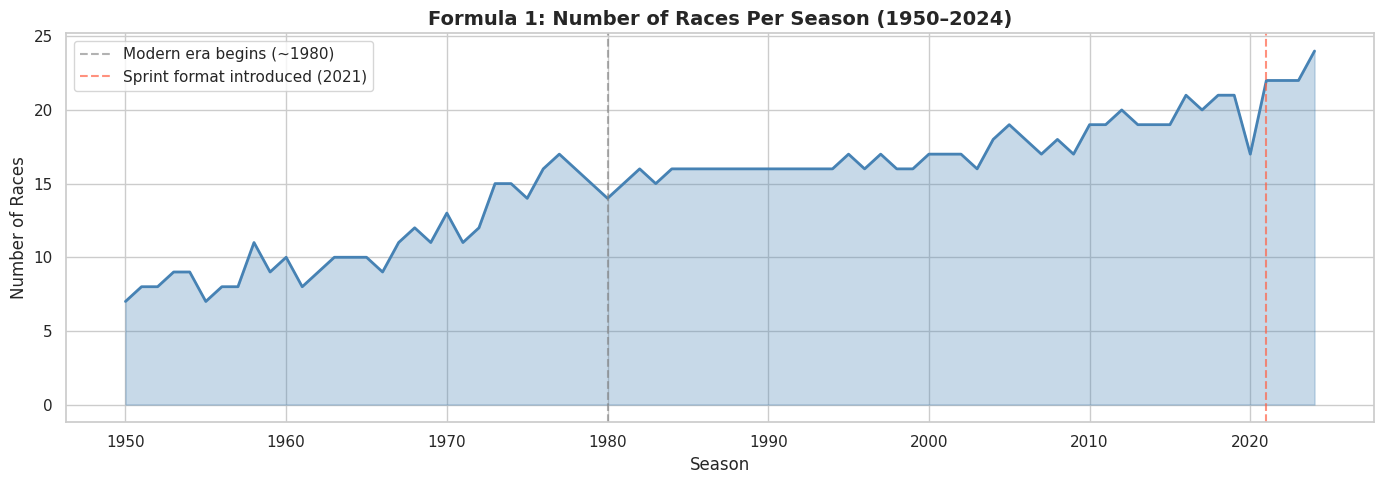

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(rps['year'], rps['num_races'], alpha=0.3, color='steelblue')
ax.plot(rps['year'], rps['num_races'], color='steelblue', linewidth=2)
ax.axvline(1980, color='gray', linestyle='--', alpha=0.6, label='Modern era begins (~1980)')
ax.axvline(2021, color='tomato', linestyle='--', alpha=0.7, label='Sprint format introduced (2021)')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Number of Races', fontsize=12)
ax.set_title('Formula 1: Number of Races Per Season (1950–2024)', fontsize=14, fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.show()
print(f'\n1950s avg races/season: {rps[rps.year<1960]["num_races"].mean():.1f}')
print(f'2010s avg races/season: {rps[(rps.year>=2010)&(rps.year<2020)]["num_races"].mean():.1f}')
print(f'2020s avg races/season: {rps[rps.year>=2020]["num_races"].mean():.1f}')

### 5.2 Most Frequently Hosted Circuits

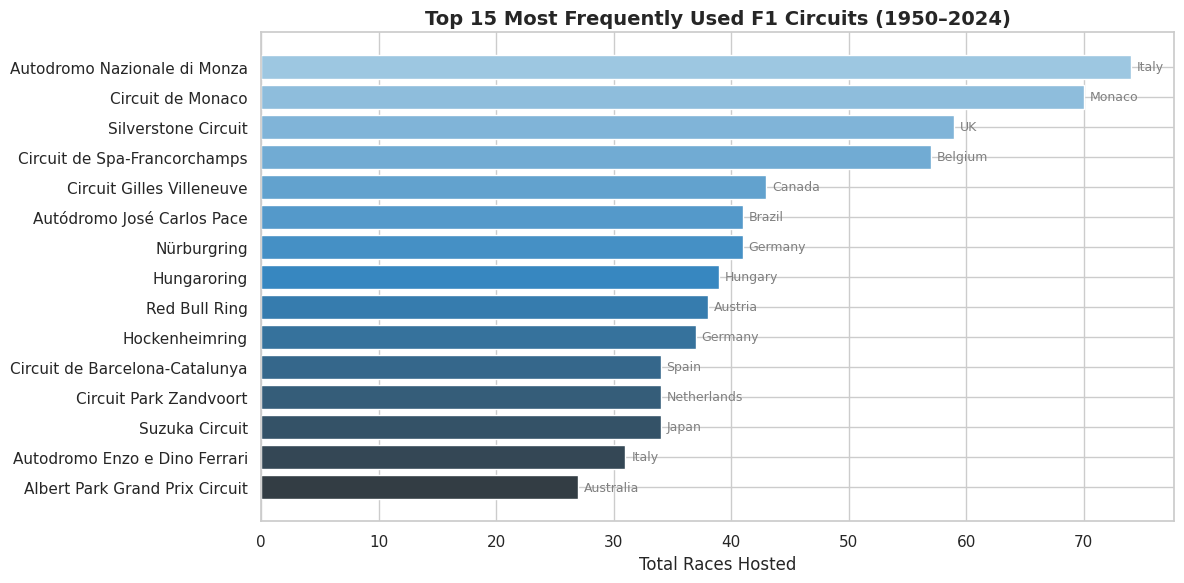

In [9]:
top_circuits = (
    df.groupby(['name_circuit', 'country'])['raceId']
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_circuits.columns = ['Circuit', 'Country', 'Races Held']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_circuits['Circuit'], top_circuits['Races Held'],
               color=sns.color_palette('Blues_d', 15))
ax.invert_yaxis()
ax.set_xlabel('Total Races Hosted', fontsize=12)
ax.set_title('Top 15 Most Frequently Used F1 Circuits (1950–2024)', fontsize=14, fontweight='bold')
for bar, country in zip(bars, top_circuits['Country']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            country, va='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

### 5.3 Race Hosting by Country

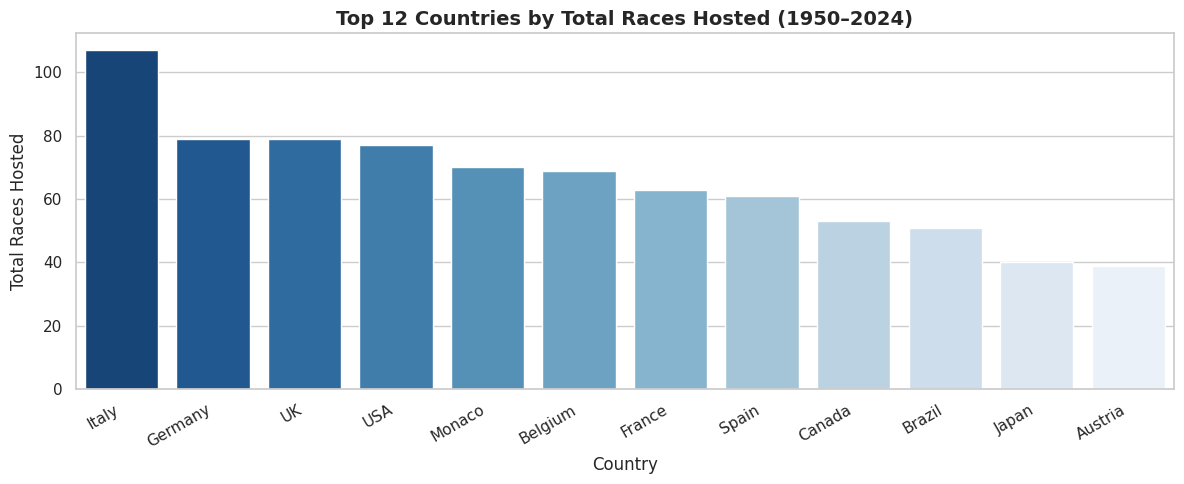

In [10]:
country_counts = (
    df.groupby('country')['raceId']
    .count()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)
country_counts.columns = ['Country', 'Races Held']

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=country_counts, x='Country', y='Races Held', hue='Country', palette='Blues_r', legend=False, ax=ax)
ax.set_title('Top 12 Countries by Total Races Hosted (1950–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Total Races Hosted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 5.4 Race Month Distribution — When Does F1 Race?

Peak month: Jul - 184 races


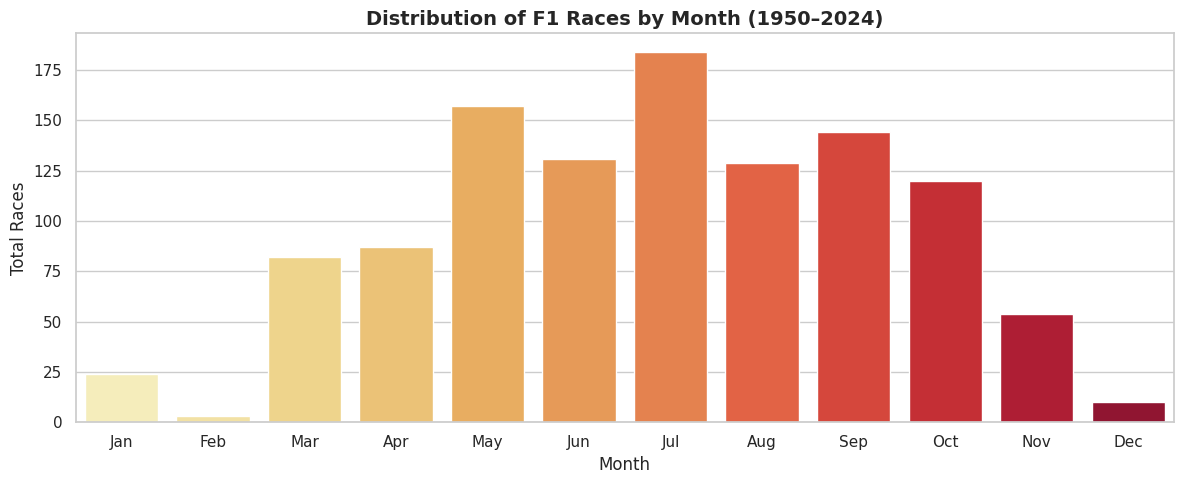

In [11]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_dist = (
    races.groupby('month_name')['raceId']
    .count()
    .reindex(month_order)
    .reset_index()
)
month_dist.columns = ['Month', 'Races']

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=month_dist, x='Month', y='Races', hue='Month', palette='YlOrRd', legend=False, ax=ax)
ax.set_title('Distribution of F1 Races by Month (1950–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Races')
plt.tight_layout()
plt.show()
print('Peak month:', month_dist.loc[month_dist['Races'].idxmax(), 'Month'],
      '-', month_dist['Races'].max(), 'races')

### 5.5 Circuit Debuts Over Time — Geographic Expansion

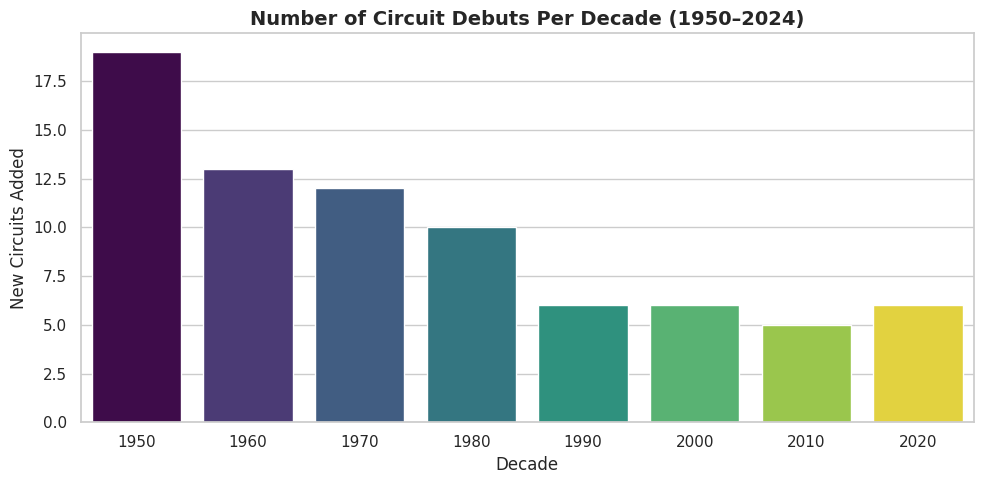

In [12]:
# Year each circuit first appeared
first_appearance = df.groupby('circuitId')['year'].min().reset_index()
first_appearance.columns = ['circuitId', 'debut_year']
debuts_by_decade = first_appearance.copy()
debuts_by_decade['decade'] = (debuts_by_decade['debut_year'] // 10) * 10
debut_counts = debuts_by_decade.groupby('decade')['circuitId'].count().reset_index()
debut_counts.columns = ['Decade', 'New Circuits']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=debut_counts, x='Decade', y='New Circuits', hue='Decade', palette='viridis', legend=False, ax=ax)
ax.set_title('Number of Circuit Debuts Per Decade (1950–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('New Circuits Added')
plt.tight_layout()
plt.show()

### 5.6 Growth of Sprint Race Format (2021–2024)

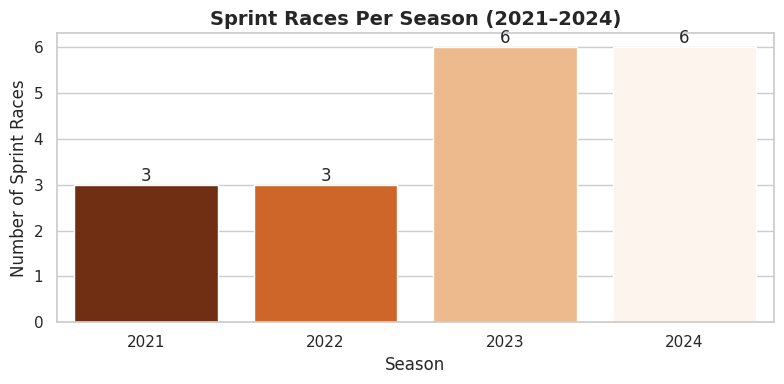

In [13]:
sprint_by_year = (
    races[races['has_sprint'] == 1]
    .groupby('year')['raceId']
    .count()
    .reset_index()
)
sprint_by_year.columns = ['Year', 'Sprint Races']

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=sprint_by_year, x='Year', y='Sprint Races', hue='Year', palette='Oranges_r', legend=False, ax=ax)
ax.set_title('Sprint Races Per Season (2021–2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Sprint Races')
ax.set_xlabel('Season')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

### 5.7 Outlier Analysis — Unusual Season Sizes

Outlier seasons:
 Empty DataFrame
Columns: [year, num_races]
Index: []


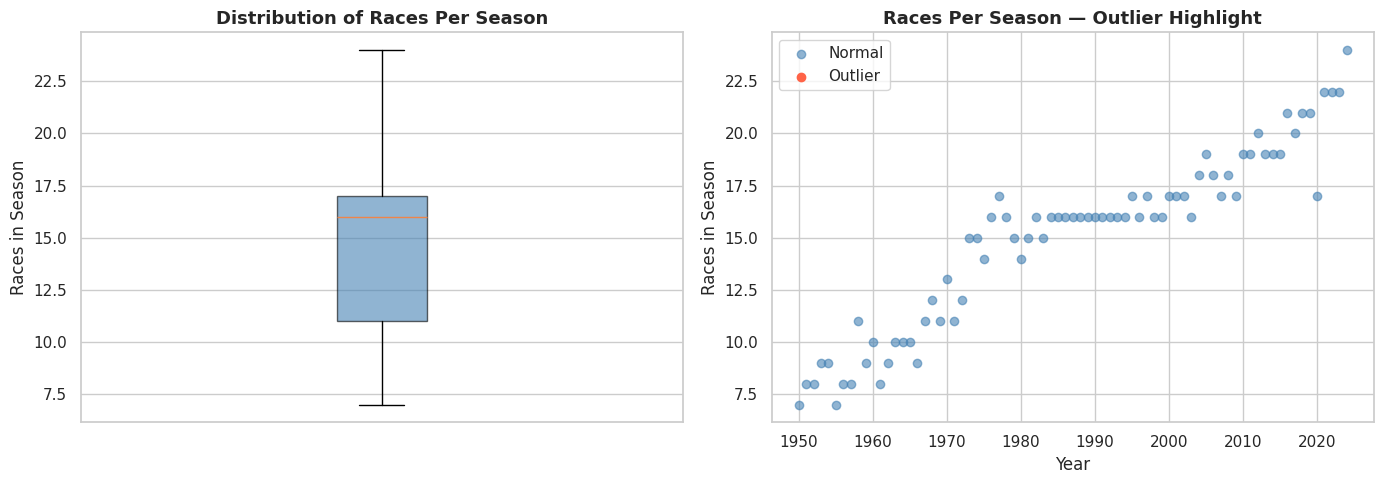

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(rps['num_races'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Distribution of Races Per Season', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Races in Season')
axes[0].set_xticks([])

# IQR-based outlier label
Q1 = rps['num_races'].quantile(0.25)
Q3 = rps['num_races'].quantile(0.75)
IQR = Q3 - Q1
outliers = rps[(rps['num_races'] < Q1 - 1.5*IQR) | (rps['num_races'] > Q3 + 1.5*IQR)]

# Scatter highlighting outliers
axes[1].scatter(rps['year'], rps['num_races'], alpha=0.6, color='steelblue', label='Normal')
axes[1].scatter(outliers['year'], outliers['num_races'], color='tomato', zorder=5, label='Outlier')
for _, row in outliers.iterrows():
    axes[1].annotate(f"{int(row['year'])} ({int(row['num_races'])})",
                     (row['year'], row['num_races']), textcoords='offset points',
                     xytext=(5, 5), fontsize=8)
axes[1].set_title('Races Per Season — Outlier Highlight', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Races in Season')
axes[1].legend()
plt.tight_layout()
plt.show()
print('Outlier seasons:\n', outliers.to_string(index=False))

## 6. Baseline Model: Predicting Number of Races Per Season

**Objective:** Build a baseline regression model to predict how many races will be held in a future season, based on historical trends.

**Evaluation Metric:** MAE (Mean Absolute Error) — the average number of races our prediction is off by. This is interpretable and directly meaningful in the scheduling domain (e.g., an MAE of 1.5 means predictions are off by ~1–2 races on average).

**Features used:**
- `year` — captures the long-term upward trend in race count
- `year_lag1` — last season's race count (autoregressive feature)

**Rationale for Linear Regression as baseline:** Simple, interpretable, and appropriate for a time-series trend prediction where the relationship between year and race count is broadly linear over the modern era. More complex models (e.g., ARIMA, Random Forest) will be explored in Module 24.

In [15]:
# Build time-series feature set
rps['year_lag1'] = rps['num_races'].shift(1)  # previous season race count
rps_model = rps.dropna().copy()

X = rps_model[['year', 'year_lag1']]
y = rps_model['num_races']

# Chronological train/test split (no shuffle — preserve time order)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f'Training seasons: {int(X_train["year"].min())}–{int(X_train["year"].max())}')
print(f'Test seasons:     {int(X_test["year"].min())}–{int(X_test["year"].max())}')

Training seasons: 1951–2009
Test seasons:     2010–2024


In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)

# Cross-validation
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')

print('=== Baseline Model: Linear Regression ===')
print(f'MAE:          {mae:.2f} races')
print(f'RMSE:         {rmse:.2f} races')
print(f'R²:           {r2:.3f}')
print(f'CV R² (mean): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

=== Baseline Model: Linear Regression ===
MAE:          1.13 races
RMSE:         1.62 races
R²:           0.094
CV R² (mean): -0.410 ± 0.726


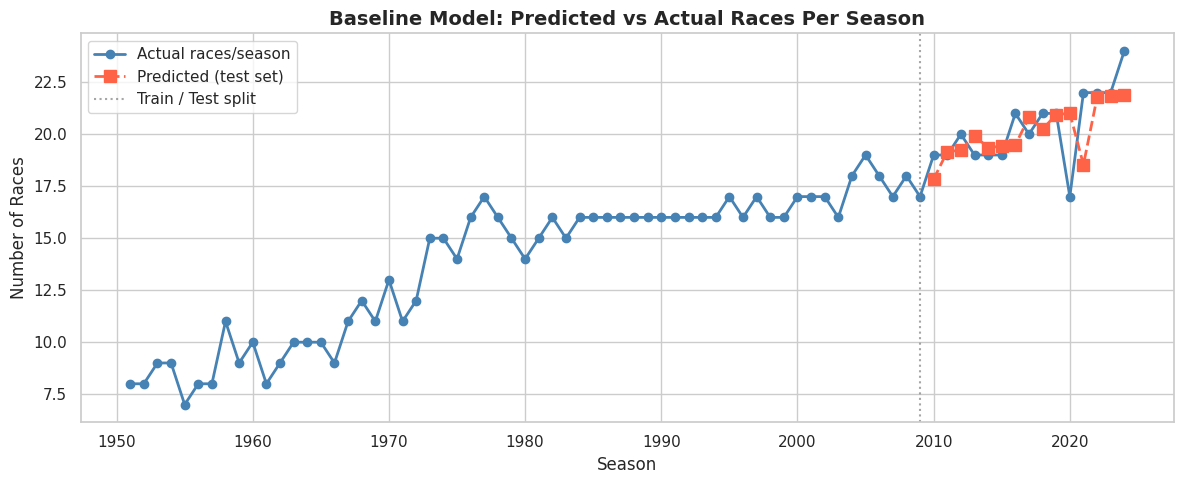

In [17]:
# Visualize predictions vs actuals
test_years = X_test['year'].values

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rps_model['year'], rps_model['num_races'], 'o-', color='steelblue',
        label='Actual races/season', linewidth=2)
ax.plot(test_years, pred, 's--', color='tomato', markersize=8,
        label='Predicted (test set)', linewidth=2)
ax.axvline(X_train['year'].max(), color='gray', linestyle=':', alpha=0.7,
           label='Train / Test split')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Number of Races', fontsize=12)
ax.set_title('Baseline Model: Predicted vs Actual Races Per Season', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Feature coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
print(coef_df.to_string(index=False))
print(f'Intercept: {lr.intercept_:.2f}')

  Feature  Coefficient
     year     0.063619
year_lag1     0.633510
Intercept: -120.81


## 7. Summary of Findings

### Key EDA Insights
1. **Steady growth in race count**: F1 has expanded from 7 races in 1950 to 24 in 2024, with a consistent upward trend since the mid-1980s.
2. **Classic circuits dominate longevity**: Monza (74), Monaco (70), and Silverstone (59) are the most frequently used circuits — though newer venues are increasingly added each decade.
3. **European bias is eroding**: Historically dominated by Italy, Germany, UK, and France, F1 has steadily added circuits in the Middle East, Asia, and the Americas since the 2000s.
4. **Racing season is March–November**: July is the busiest month; December and February are rarely used. This is driven by weather, logistics, and broadcast scheduling.
5. **Sprint format is scaling**: Introduced in 2021 with 3 events, sprints grew to 6 per season by 2023–2024, indicating a deliberate strategic push.
6. **Outlier seasons**: The COVID-shortened 2020 season (17 races) and very early seasons (1950s: 7–9 races) appear as statistical outliers.

### Baseline Model Results
A Linear Regression model using `year` and the prior season's race count (`year_lag1`) as features achieved:
- **MAE ≈ 1.1 races** — predictions are off by about 1 race per season on average
- **R² ≈ 0.09** — the model captures some trend but leaves room for improvement
- The low R² reflects the model's difficulty handling sudden changes (COVID, rapid post-2020 expansion)

### Next Steps (Module 24)
- Incorporate additional features: continent diversity index, new circuit debut flag, decade indicators
- Try ARIMA or Prophet for proper time-series forecasting
- Clustering circuits by geography and appearance frequency
- Classification model: predict whether a given circuit will appear in the *next* season's calendar